## **Customer Churn Prediction**

In [320]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
import joblib

In [321]:
from google.colab import files

In [322]:
train=pd.read_csv('trainfile.csv')

<ipython-input-322-bd61b1450dad>:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  train=pd.read_csv('trainfile.csv')


In [323]:
test=pd.read_csv('testfile.csv')

<ipython-input-323-7dab8d62609c>:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  test=pd.read_csv('testfile.csv')


# **Exploratory Data Analysis**


In [324]:
train.head()

,row ID,CustomerId,Surname,CreditScore,Geography,Gender,Dependents,Age,Tenure,Balance,Occupation,OwnHouse,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668.0,France,Male,0,33.0,3.0,0.00,student,0.0,2.0,1.0,0,181449.97,0
1,1,15749177,Okwudiliolisa,627.0,France,Male,0,33.0,1.0,0.00,student,0.0,2.0,1.0,1,49503.50,0
2,2,15694510,Hsueh,678.0,France,Male,1,40.0,10.0,0.00,unemployed,1.0,2.0,1.0,0,184866.69,0
3,3,15741417,Kao,581.0,France,Male,2,34.0,2.0,148882.54,student,0.0,1.0,1.0,1,84560.88,0
4,5,15771669,Genovese,588.0,Germany,Male,2,36.0,4.0,131778.58,self employed,1.0,1.0,1.0,0,136024.31,1


In [325]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184839 entries, 0 to 184838
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   row ID           184839 non-null  object 
 1   CustomerId       184839 non-null  int64  
 2   Surname          184839 non-null  object 
 3   CreditScore      184839 non-null  float64
 4   Geography        184839 non-null  object 
 5   Gender           184839 non-null  object 
 6   Dependents       184839 non-null  int64  
 7   Age              184839 non-null  float64
 8   Tenure           184839 non-null  float64
 9   Balance          184839 non-null  float64
 10  Occupation       184839 non-null  object 
 11  OwnHouse         184675 non-null  float64
 12  NumOfProducts    184839 non-null  float64
 13  HasCrCard        184689 non-null  float64
 14  IsActiveMember   184839 non-null  int64  
 15  EstimatedSalary  184839 non-null  float64
 16  Exited           184839 non-null  int6

In [326]:
train.shape

(184839, 17)

In [327]:
train.describe()

,CustomerId,CreditScore,Dependents,Age,Tenure,Balance,OwnHouse,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.848390e+05,184839.000000,184839.000000,184839.000000,184839.000000,184839.000000,184675.000000,184839.000000,184689.000000,184839.000000,184839.000000,184839.000000
mean,1.569185e+07,656.542672,1.017978,38.041652,4.985086,54762.528959,0.503512,1.561162,0.753662,0.498482,113827.614029,0.211411
std,7.135536e+04,77.831202,0.874872,8.570119,2.710755,62409.995597,0.499989,0.533197,0.430879,0.499999,50138.006849,0.408310
min,1.556570e+07,350.000000,0.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.563321e+07,599.972438,0.000000,32.026540,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,75888.570000,0.000000
50%,1.569016e+07,659.414276,1.000000,37.000000,5.000000,0.000000,1.000000,2.000000,1.000000,0.000000,120512.568000,0.000000
75%,1.575654e+07,709.000000,2.000000,42.000000,7.000000,118897.100000,1.000000,2.000000,1.000000,1.000000,156910.787350,0.000000
max,1.581569e+07,850.000000,4.000000,92.000000,10.000000,250898.090000,1.000000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [328]:
train['Geography'].value_counts()

,count
Geography,
France,105614
Spain,40653
Germany,38572


In [329]:
train['Occupation'].value_counts()

,count
Occupation,
student,100303
self employed,31823
unemployed,28201
retired,24512


In [330]:
train['OwnHouse'].value_counts()

,count
OwnHouse,
1.0,92986
0.0,91689


In [331]:
train.isnull().sum()

,0
row ID,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Dependents,0
Age,0
Tenure,0
Balance,0


In [332]:
columns_to_remove = ['CustomerId', 'Surname']
train = train.drop(columns=columns_to_remove, axis=1)

In [333]:
train.head()

,row ID,CreditScore,Geography,Gender,Dependents,Age,Tenure,Balance,Occupation,OwnHouse,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,668.0,France,Male,0,33.0,3.0,0.00,student,0.0,2.0,1.0,0,181449.97,0
1,1,627.0,France,Male,0,33.0,1.0,0.00,student,0.0,2.0,1.0,1,49503.50,0
2,2,678.0,France,Male,1,40.0,10.0,0.00,unemployed,1.0,2.0,1.0,0,184866.69,0
3,3,581.0,France,Male,2,34.0,2.0,148882.54,student,0.0,1.0,1.0,1,84560.88,0
4,5,588.0,Germany,Male,2,36.0,4.0,131778.58,self employed,1.0,1.0,1.0,0,136024.31,1


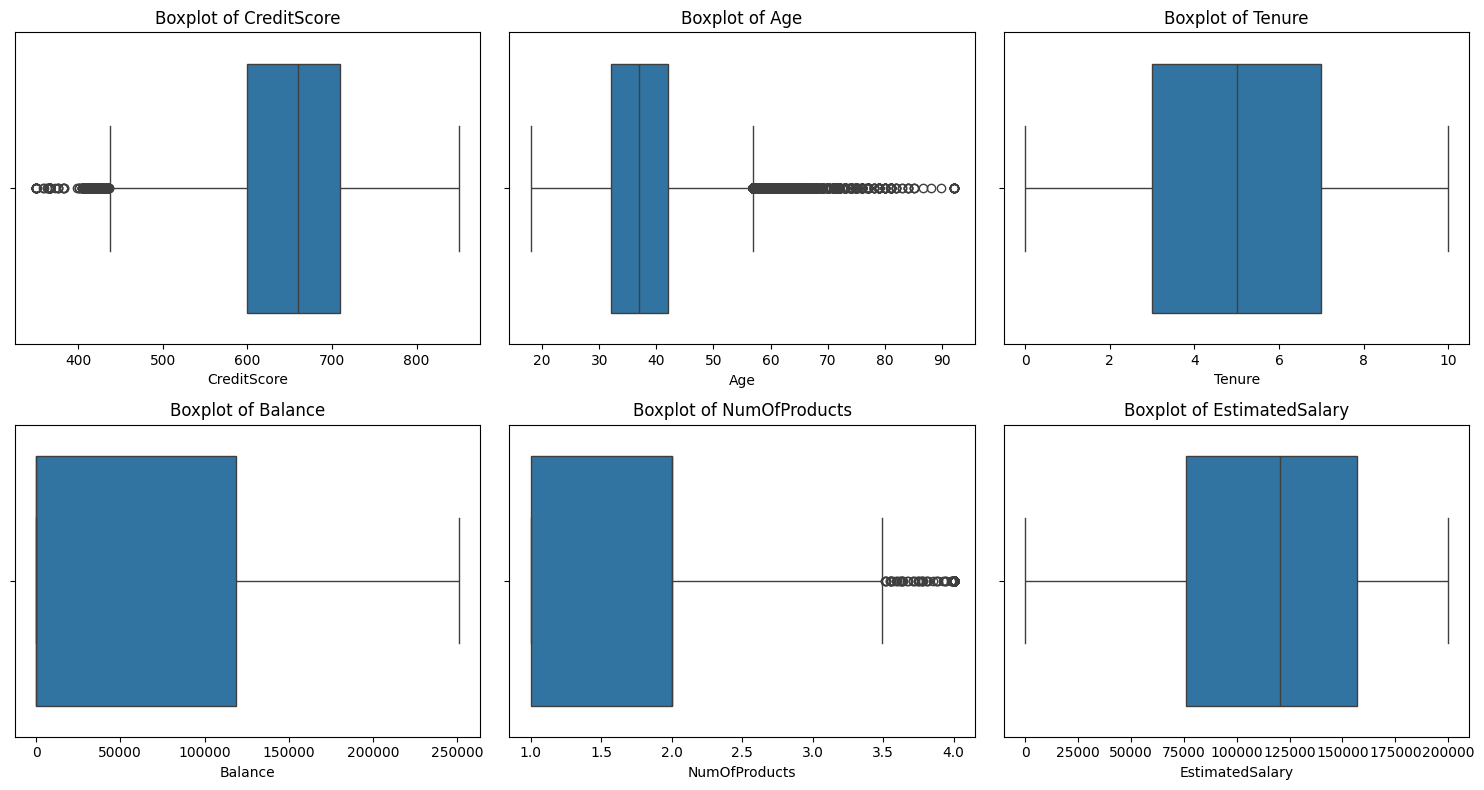

In [334]:
#Boxplot for numerical columns

numerical_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=train, x=col)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

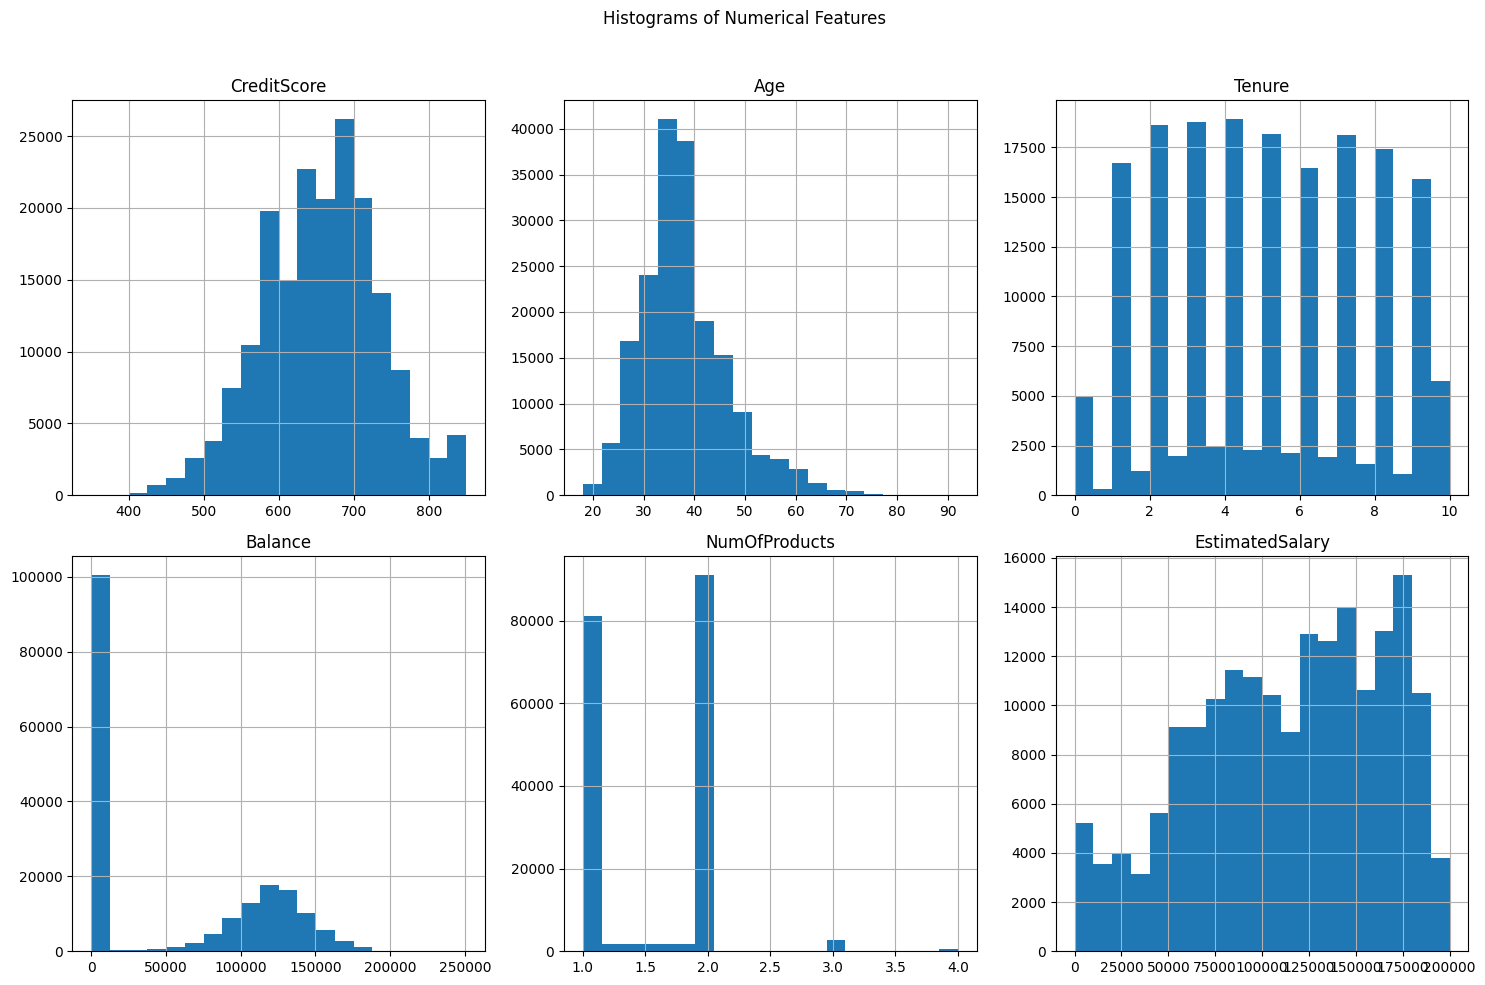

In [335]:
#Histogram for numerical features
train[numerical_columns].hist(bins=20, figsize=(15, 10), layout=(2, 3))
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

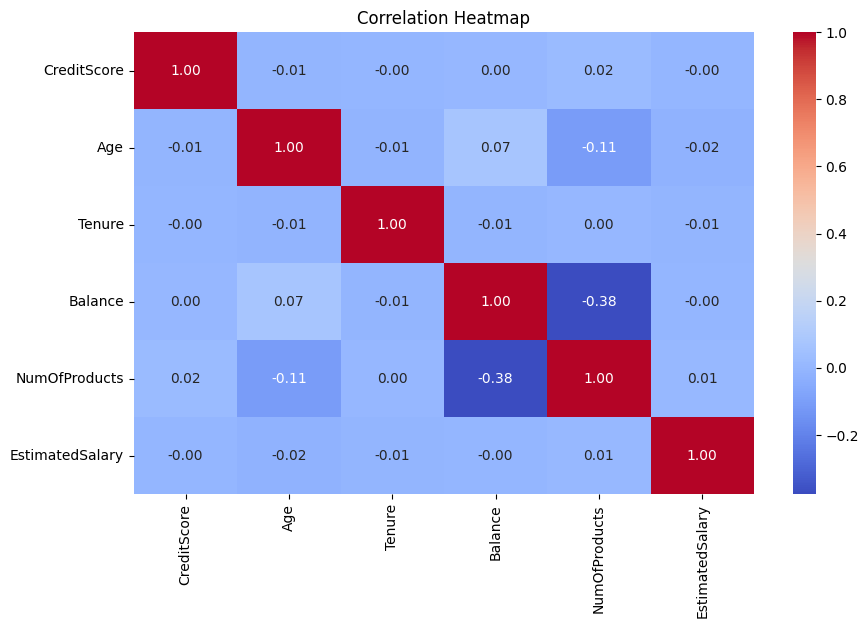

In [336]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
corr_matrix = train[numerical_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

<ipython-input-337-800f66d6efd1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x=col, palette='viridis')
<ipython-input-337-800f66d6efd1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x=col, palette='viridis')
<ipython-input-337-800f66d6efd1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x=col, palette='viridis')


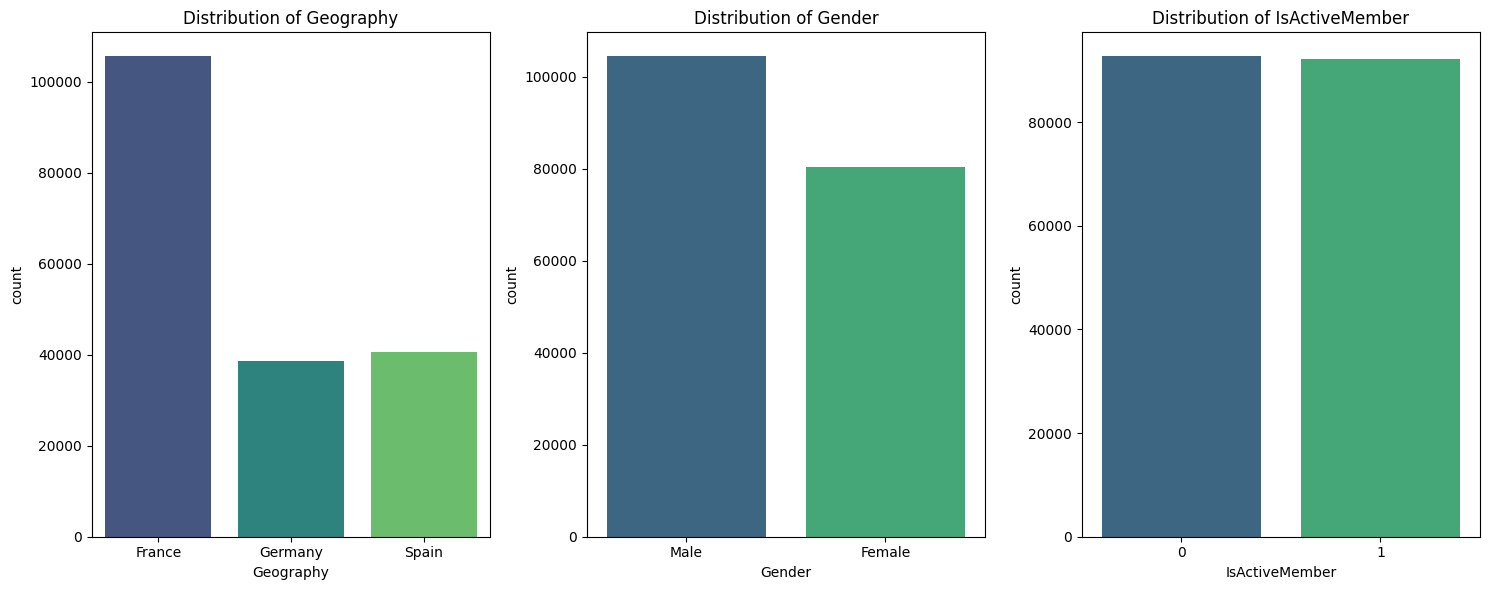

In [337]:
# Count plot for categorical features
categorical_columns = ['Geography', 'Gender', 'IsActiveMember']
plt.figure(figsize=(15, 6))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=train, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


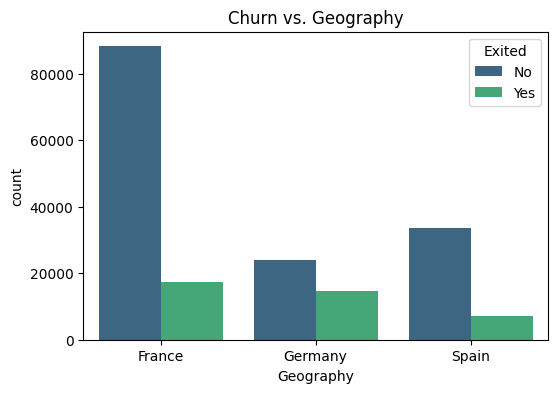

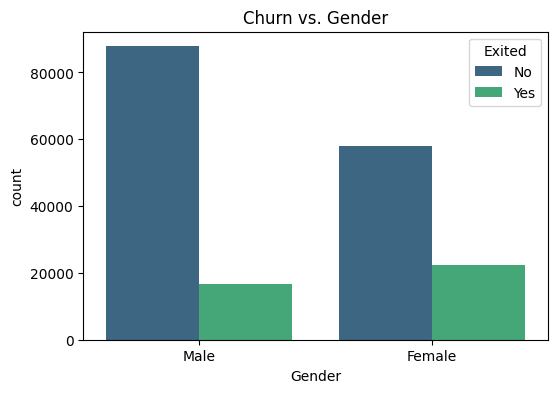

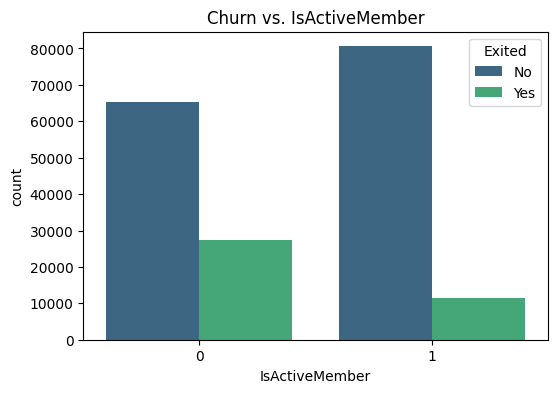

In [338]:
# Churn vs Categorical Variables
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=train, x=col, hue='Exited', palette='viridis')
    plt.title(f'Churn vs. {col}')
    plt.legend(title='Exited', labels=['No', 'Yes'])
    plt.show()


<ipython-input-339-a3e705b6a770>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Exited', y=col, palette='coolwarm')
<ipython-input-339-a3e705b6a770>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Exited', y=col, palette='coolwarm')
<ipython-input-339-a3e705b6a770>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Exited', y=col, palette='coolwarm')
<ipython-input-339-a3e705b6a770>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

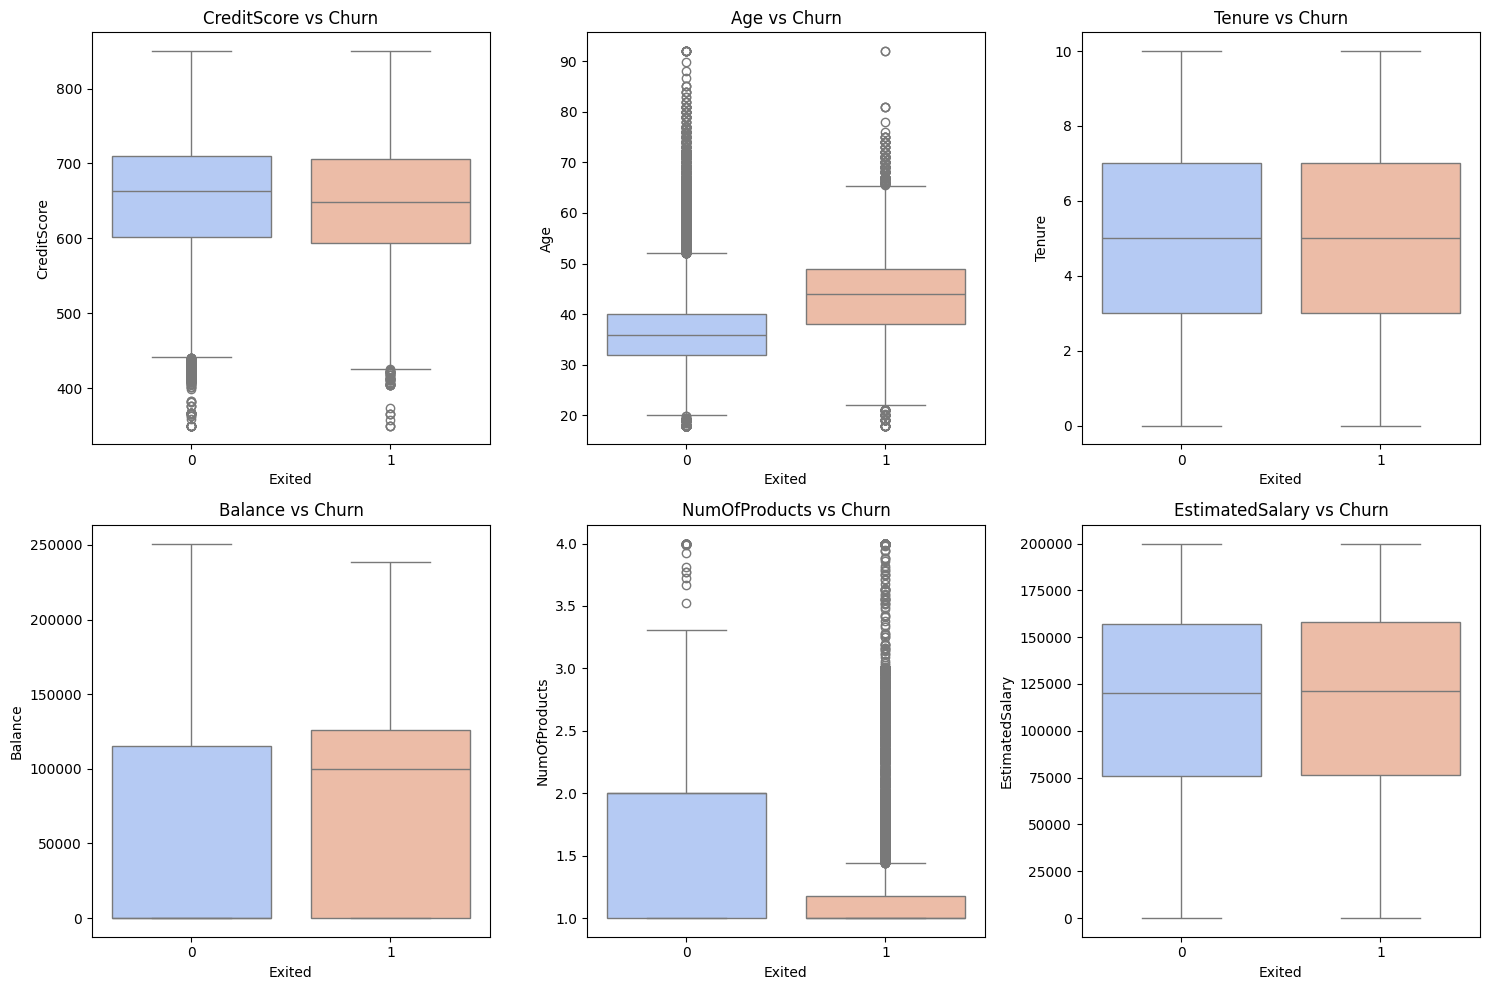

In [339]:
#Boxplot for numerical
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=train, x='Exited', y=col, palette='coolwarm')
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.show()


# **Feature Engineering & Encoding**

In [340]:
# Remove duplicates
train = train.drop_duplicates()

# Handle missing values
# We will replace missing values in numerical columns with the median
numerical_columns = train.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    train[col].fillna(train[col].median(), inplace=True)

# For categorical columns, we will fill missing values with the mode.
categorical_columns = train.select_dtypes(include=['object']).columns
for col in categorical_columns:
    train[col].fillna(train[col].mode()[0], inplace=True)

print(train.isnull().sum())

<ipython-input-340-7b9c3250a855>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(), inplace=True)
<ipython-input-340-7b9c3250a855>:13: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  train[col].fillna(train[col].mode()[0], inplace=True)
<ipython-input-340-7b9c3250a855>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This in

row ID             0
CreditScore        0
Geography          0
Gender             0
Dependents         0
Age                0
Tenure             0
Balance            0
Occupation         0
OwnHouse           0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [341]:
train.reset_index(drop=True, inplace=True)
train.head()

,row ID,CreditScore,Geography,Gender,Dependents,Age,Tenure,Balance,Occupation,OwnHouse,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,668.0,France,Male,0,33.0,3.0,0.00,student,0.0,2.0,1.0,0,181449.97,0
1,1,627.0,France,Male,0,33.0,1.0,0.00,student,0.0,2.0,1.0,1,49503.50,0
2,2,678.0,France,Male,1,40.0,10.0,0.00,unemployed,1.0,2.0,1.0,0,184866.69,0
3,3,581.0,France,Male,2,34.0,2.0,148882.54,student,0.0,1.0,1.0,1,84560.88,0
4,5,588.0,Germany,Male,2,36.0,4.0,131778.58,self employed,1.0,1.0,1.0,0,136024.31,1


In [342]:
train1=train.copy()

In [343]:
categorical_columns=['Geography','Gender','Occupation']

In [344]:
train1 = pd.get_dummies(train, columns=['Geography'], drop_first=True)

train1.head()

,row ID,CreditScore,Gender,Dependents,Age,Tenure,Balance,Occupation,OwnHouse,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,0,668.0,Male,0,33.0,3.0,0.00,student,0.0,2.0,1.0,0,181449.97,0,False,False
1,1,627.0,Male,0,33.0,1.0,0.00,student,0.0,2.0,1.0,1,49503.50,0,False,False
2,2,678.0,Male,1,40.0,10.0,0.00,unemployed,1.0,2.0,1.0,0,184866.69,0,False,False
3,3,581.0,Male,2,34.0,2.0,148882.54,student,0.0,1.0,1.0,1,84560.88,0,False,False
4,5,588.0,Male,2,36.0,4.0,131778.58,self employed,1.0,1.0,1.0,0,136024.31,1,True,False


In [345]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

train1['Gender']=label_encoder.fit_transform(train1['Gender'])
train1['Occupation']=label_encoder.fit_transform(train1['Occupation'])

print(train1.head())

  row ID  CreditScore  Gender  ...  Exited  Geography_Germany  Geography_Spain
0      0        668.0       1  ...       0              False            False
1      1        627.0       1  ...       0              False            False
2      2        678.0       1  ...       0              False            False
3      3        581.0       1  ...       0              False            False
4      5        588.0       1  ...       1               True            False

[5 rows x 16 columns]


# **Data Splitting**

In [370]:
train1=train1.drop(columns=['row ID'])

In [371]:
X = train1.drop(columns=['Exited'])
y = train1['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of the resulting splits
print(f"Training set features: {X_train.shape}")
print(f"Testing set features: {X_test.shape}")
print(f"Training set target: {y_train.shape}")
print(f"Testing set target: {y_test.shape}")


Training set features: (147871, 14)
Testing set features: (36968, 14)
Training set target: (147871,)
Testing set target: (36968,)


In [373]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (147871, 14)
Shape of X_test: (36968, 14)
Shape of y_train: (147871,)
Shape of y_test: (36968,)


In [374]:
train1.head()

,CreditScore,Gender,Dependents,Age,Tenure,Balance,Occupation,OwnHouse,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,668.0,1,0,33.0,3.0,0.00,2,0.0,2.0,1.0,0,181449.97,0,False,False
1,627.0,1,0,33.0,1.0,0.00,2,0.0,2.0,1.0,1,49503.50,0,False,False
2,678.0,1,1,40.0,10.0,0.00,3,1.0,2.0,1.0,0,184866.69,0,False,False
3,581.0,1,2,34.0,2.0,148882.54,2,0.0,1.0,1.0,1,84560.88,0,False,False
4,588.0,1,2,36.0,4.0,131778.58,1,1.0,1.0,1.0,0,136024.31,1,True,False


# **Model Training**

In [375]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

dt_classifier = DecisionTreeClassifier(random_state=42)

dt_classifier.fit(X_train, y_train)

y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8451


In [377]:
# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     29241
           1       0.63      0.64      0.63      7727

    accuracy                           0.85     36968
   macro avg       0.77      0.77      0.77     36968
weighted avg       0.85      0.85      0.85     36968

Confusion Matrix:
[[26335  2906]
 [ 2819  4908]]


In [379]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=3)

# **Model Testing**

In [380]:
test.head()

,row ID,CustomerId,Surname,CreditScore,Geography,Gender,Dependents,Age,Tenure,Balance,Occupation,OwnHouse,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,4,15766172,Chiemenam,716.0,Spain,Male,1,33.0,5.0,0.00,student,0,2.0,1,1,15068.83
1,6,15692819,Ch'ang,593.0,France,Female,0,30.0,8.0,144772.69,self employed,1,1.0,1,0,29792.11
2,8,15691707,Manna,676.0,France,Male,1,43.0,4.0,0.00,unemployed,1,2.0,1,0,142917.13
3,11,15674671,Chiu,687.0,Germany,Male,2,40.0,3.0,90432.92,unemployed,0,1.0,1,0,1676.92
4,12,15717962,Rossi,759.0,Spain,Male,1,71.0,9.0,0.00,retired,1,1.0,1,1,93081.87


In [381]:
test.shape

(79217, 16)

In [382]:
test=test.drop(columns=['CustomerId','Surname'])
test['Gender']=test['Gender'].map({'Male': 0, 'Female': 1})

In [384]:
test = test.drop_duplicates()

# Handle missing values
# We will replace missing values in numerical columns with the median
numerical_columns = test.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    test[col].fillna(test[col].median(), inplace=True)

# For categorical columns, we will fill missing values with the mode.
categorical_columns = test.select_dtypes(include=['object']).columns
for col in categorical_columns:
    test[col].fillna(train[col].mode()[0], inplace=True)

print(test.isnull().sum())


row ID             0
CreditScore        0
Geography          0
Gender             0
Dependents         0
Age                0
Tenure             0
Balance            0
Occupation         0
OwnHouse           0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64


<ipython-input-384-fbd59a6d4d6d>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col].fillna(test[col].median(), inplace=True)
<ipython-input-384-fbd59a6d4d6d>:12: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  test[col].fillna(train[col].mode()[0], inplace=True)
<ipython-input-384-fbd59a6d4d6d>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inpla

In [385]:
test.reset_index(drop=True, inplace=True)

In [386]:
test = pd.get_dummies(test, columns=['Geography'], drop_first=True)

In [387]:

test['Gender']=label_encoder.fit_transform(test['Gender'])
test['Occupation']=label_encoder.fit_transform(test['Occupation'])

In [388]:
test2=test.copy()

In [389]:
test2.drop(columns='row ID',inplace=True)

In [390]:
# Check the shapes of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


Shape of X: (184839, 14)
Shape of y: (184839,)


In [391]:
print(len(y_pred))  # Length of the predictions array
print(len(test))

36968
79217


In [392]:
y_pred=model.predict(test2)

In [393]:
submission = pd.DataFrame({
    'row ID': test['row ID'],
    'Exited': y_pred
})


In [394]:
submission.to_csv('submission.csv', index=False)